<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
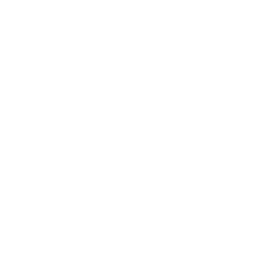
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Perfilado de Riesgo de Clientes mediante Discriminación Canónica</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Servicios Financieros / Analítica de Riesgo de Crédito &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen ejecutivo

Tres grupos de estado del préstamo en una cartera hipotecaria de consumo —**en impago (defaulted)**, **al corriente (current)** y **prepagado (prepaid)**— difieren en varias dimensiones de salud financiera a la vez, lo que hace que cualquier ratio aislado sea una señal de riesgo débil. Este cuaderno aplica **PROC CANDISC** (análisis discriminante canónico) a una muestra de revisión de riesgo de 100 clientes, condensando seis ratios financieros correlacionados en dos dimensiones canónicas que maximizan la separación entre los tres grupos de estado.

La primera dimensión canónica concentra casi toda la separación entre grupos —correlación canónica **0.958**, compartiendo el **91.8%** de su varianza con la pertenencia al grupo— y ordena a los prestatarios de forma limpia desde defaulted en un extremo hasta prepaid en el otro. La segunda dimensión (correlación canónica **0.503**, al cuadrado **0.254**) añade un contraste secundario liderado por el historial de morosidad y el apalancamiento. Las distancias de Mahalanobis al cuadrado confirman que los centroides de **DEFAULT** y **PREPAID** son el par más ampliamente separado (**75.3**), con **CURRENT** situándose entre ellos (34.3 de DEFAULT, 10.1 de PREPAID). Las puntuaciones canónicas resultantes forman un índice de riesgo compuesto y compacto, adecuado para la segmentación de carteras y la calibración de scorecards.

## Fuentes de datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | Ratios financieros sintéticos de clientes y métricas de comportamiento, etiquetados por estado del préstamo, extraídos como una muestra equilibrada de revisión de riesgo | 100 |

La muestra sobrerrepresenta deliberadamente las cuentas en impago y prepagadas (una extracción de tipo caso–control) para que cada grupo de estado sea lo bastante grande como para estimar una estructura de covarianza intragrupo estable para el análisis discriminante.

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic loan-customer risk-review sample.
   Three status groups (DEFAULT / CURRENT / PREPAID) are
   over-sampled toward the risk tails so each class is large
   enough for a stable within-group covariance estimate.
   -------------------------------------------------------- */
DATOS work.loan_profiles;
    LLAMAR streaminit(42);
    LONGITUD loan_status $10 vintage $7 customer_id $12;
    ARREGLO statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    ARREGLO vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    HACER i = 1 HASTA 20000;
        customer_id = cat('CUST-', PUT(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        SI status_prob < 0.30 ENTONCES status_idx = 1;       /* DEFAULT */
        SINO SI status_prob < 0.70 ENTONCES status_idx = 2;  /* CURRENT */
        SINO status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        /* Financial ratios separate the three status groups */
        SI loan_status = 'DEFAULT' ENTONCES HACER;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        END;
        SINO SI loan_status = 'CURRENT' ENTONCES HACER;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        END;
        SINO HACER;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        END;
        /* Round and constrain ratios to valid ranges */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        SI dti_ratio < 0.05 ENTONCES dti_ratio = 0.05;
        SI dti_ratio > 0.99 ENTONCES dti_ratio = 0.99;
        SI ltv_ratio < 0.10 ENTONCES ltv_ratio = 0.10;
        SI ltv_ratio > 1.20 ENTONCES ltv_ratio = 1.20;
        SI credit_utilization < 0.01 ENTONCES credit_utilization = 0.01;
        SI credit_utilization > 0.99 ENTONCES credit_utilization = 0.99;
        SALIDA;
    END;
    ELIMINAR i status_prob status_idx;
EJECUTAR;


NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  6.99 seconds
  cpu   6.99 seconds


---

### Perfiles de grupo de referencia

Antes de condensar los ratios, se resume cómo difieren los tres grupos de estado una variable a la vez, y se confirma la composición de la muestra entre las cosechas de originación.

                           Distribuciones base de ratios financieros por estado del préstamo                            

                                                  The MEANS Procedure

                                   Analysis Variable : dti_ratio Ratio deuda-ingreso

        Estado del préstamo           N Obs           Mean        Std Dev
        -----------------------------------------------------------------
        CURRENT                          46          0.331          0.112
        DEFAULT                          29          0.570          0.114
        PREPAID                          25          0.216          0.056
        -----------------------------------------------------------------

                                  Analysis Variable : ltv_ratio Ratio préstamo-valor

        Estado del préstamo           N Obs           Mean        Std Dev
        -----------------------------------------------------------------
        CURRENT                          4


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_loan_status.spec.json
NOTE: PROC FREQ statement used.


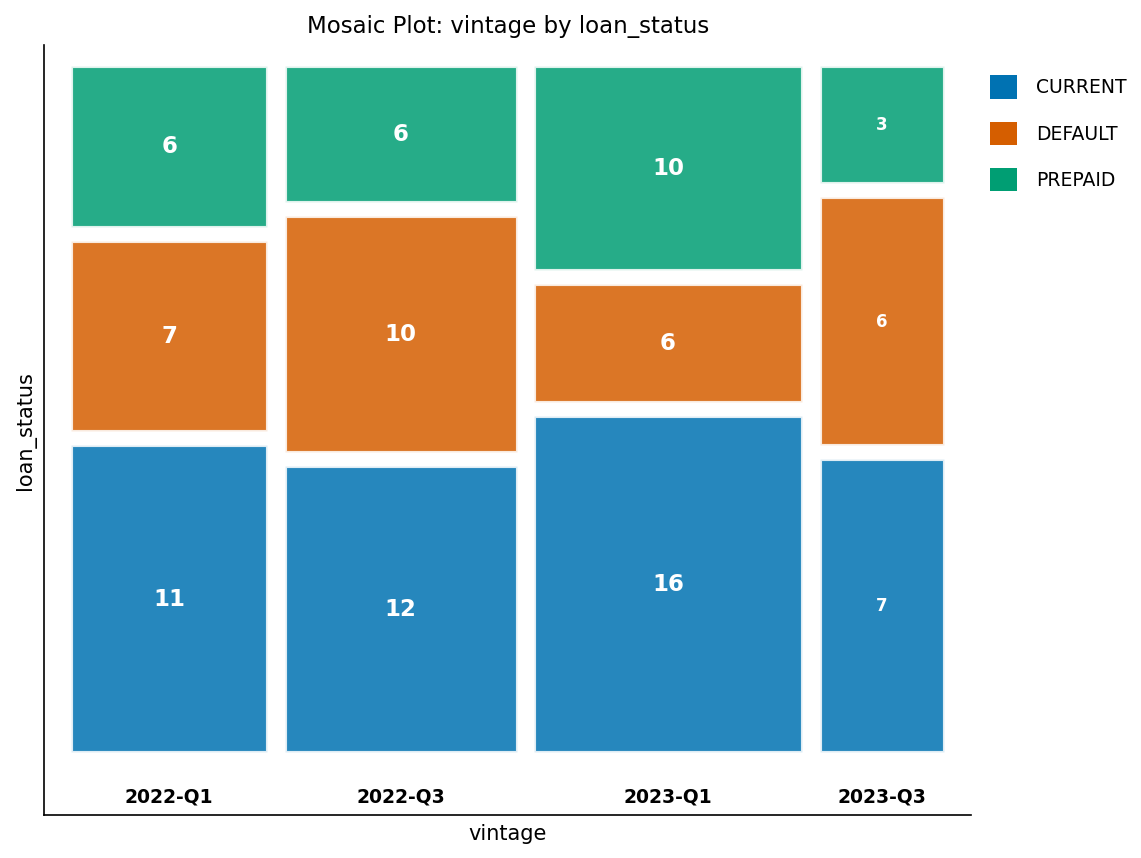

In [2]:
/* --------------------------------------------------------
   Distribuciones base de ratios financieros por estado del préstamo
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.loan_profiles n mean std maxdec=3;
    CLASE loan_status;
    VAR dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    ETIQUETA loan_status='Estado del préstamo' vintage='Cosecha'
            dti_ratio='Ratio deuda-ingreso' ltv_ratio='Ratio préstamo-valor'
            payment_to_income='Ratio pago-ingreso' credit_utilization='Utilización de crédito'
            savings_balance='Saldo de ahorros' months_delinquent='Meses en mora';
    TÍTULO 'Distribuciones base de ratios financieros por estado del préstamo';
EJECUTAR;

/* --------------------------------------------------------
   Composición de la muestra por cosecha y estado
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.loan_profiles;
    TABLES vintage * loan_status / nocum nopercent;
    ETIQUETA vintage='Cosecha' loan_status='Estado del préstamo';
    TÍTULO 'Composición de la muestra por cosecha y estado';
EJECUTAR;

---

### Análisis discriminante canónico

Ajusta un único modelo discriminante canónico agrupado sobre los 100 clientes. `OUT=` escribe las puntuaciones canónicas por cliente, `OUTSTAT=` captura la estructura canónica, los centroides de clase y las distancias de Mahalanobis al cuadrado, y `DISTANCE` solicita las distancias entre grupos. El procedimiento anunciado aquí es exactamente el que se ejecuta: **PROC CANDISC**.

                                     Composición de la muestra por cosecha y estado                                     




NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   CURRENT: 46
NOTE:   DEFAULT: 29
NOTE:   PREPAID: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NOTE:   Pillai's Trace        1.171545     21.68      12   184.0   0.0000
NOTE:   Hotelling-Lawley  

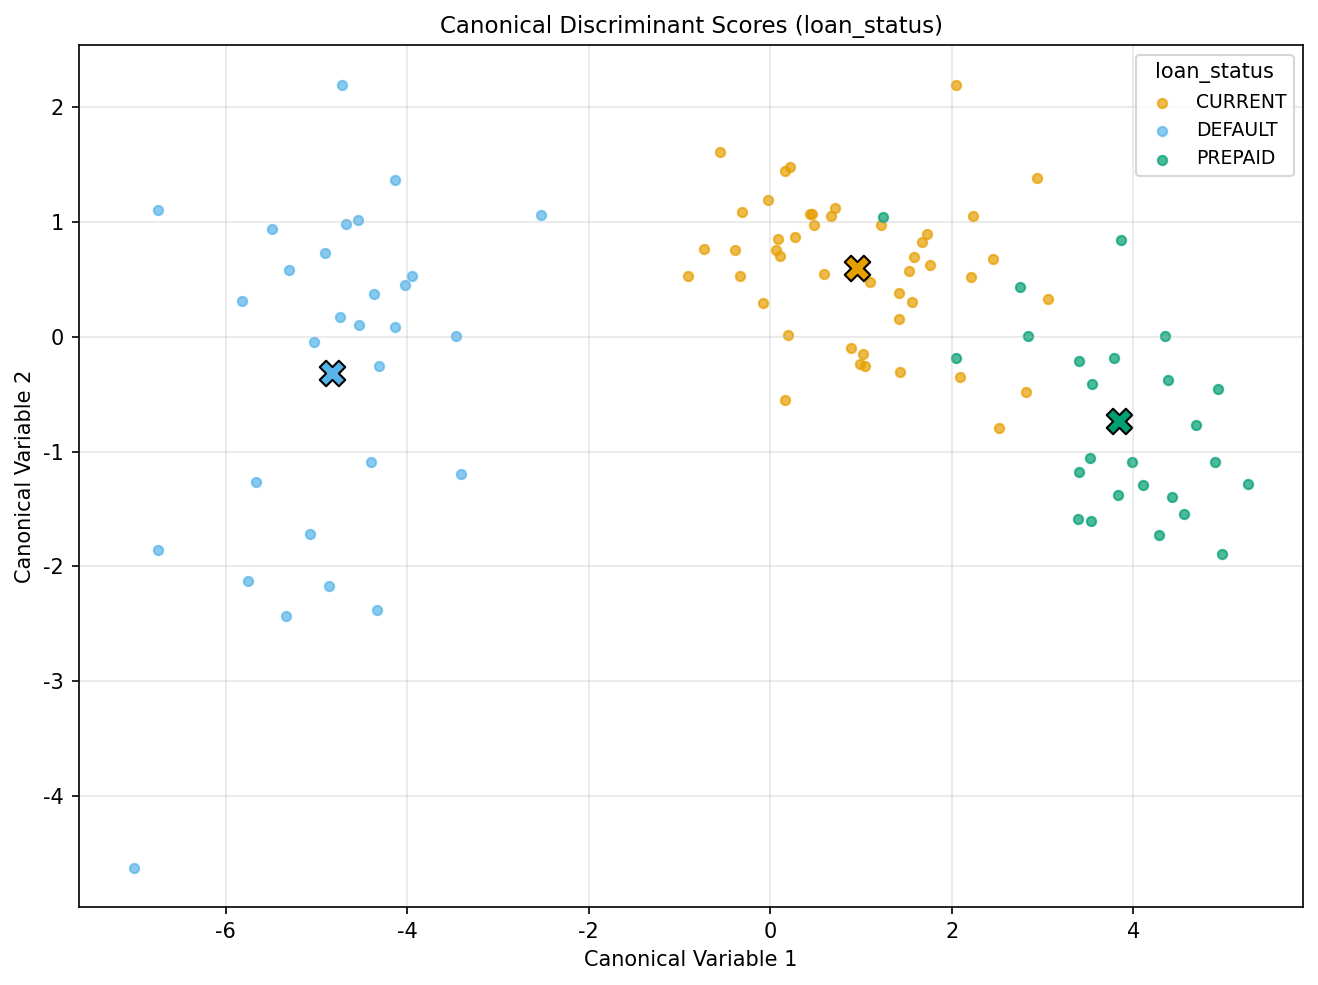

In [3]:
/* --------------------------------------------------------
   Análisis discriminante canónico de los grupos de estado del préstamo.
   OUT=    puntuaciones canónicas por cliente (Can1, Can2)
   OUTSTAT= estructura, medias de clase, distancias de Mahalanobis
   -------------------------------------------------------- */
ODS SALIDA CanonicalCorrelations=work.can_corr;

PROCEDIMIENTO CANDISC DATOS=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    CLASE loan_status;
    VAR dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    ETIQUETA loan_status='Estado del préstamo' vintage='Cosecha'
            dti_ratio='Ratio deuda-ingreso' ltv_ratio='Ratio préstamo-valor'
            payment_to_income='Ratio pago-ingreso' credit_utilization='Utilización de crédito'
            savings_balance='Saldo de ahorros' months_delinquent='Meses en mora';
    TÍTULO 'Discriminación canónica de riesgo de los grupos de estado del préstamo';
EJECUTAR;

ODS SALIDA CLOSE;

---

### Correlaciones canónicas

Cuánta de la separación entre los tres grupos captura cada dimensión canónica.

In [4]:
PROCEDIMIENTO IMPRIMIR DATOS=work.can_corr noobs;
    TÍTULO 'Correlaciones canónicas';
EJECUTAR;

                                                Correlaciones canónicas                                                 

CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488




NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### Estructura canónica (cargas de las variables)

La correlación de cada ratio financiero original con las dos dimensiones canónicas: así es como se interpretan las dimensiones.

In [5]:
PROCEDIMIENTO IMPRIMIR DATOS=work.can_stat noobs LABEL;
    DONDE _type_ = 'STRUCTUR';
    VAR _name_ Can1 Can2;
    ETIQUETA _name_='Variable' Can1='Canónica 1' Can2='Canónica 2';
    TÍTULO 'Estructura canónica intraclase agrupada';
EJECUTAR;

                                        Estructura canónica intraclase agrupada                                         

          Variable   Canónica 1   Canónica 2
dti_ratio             -0.403583    -0.022755
ltv_ratio             -0.369749     0.732657
payment_to_income     -0.304192     0.117008
credit_utilization    -0.595076    -0.056264
savings_balance         0.12558     0.093182
months_delinquent     -0.323965    -0.699884




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### Centroides de grupo y distancias de Mahalanobis

Las medias de clase sobre los ejes canónicos (los centroides de grupo) y las distancias de Mahalanobis al cuadrado entre cada par de grupos: la base para la calibración de la puntuación de riesgo.

In [6]:
PROCEDIMIENTO IMPRIMIR DATOS=work.can_stat noobs LABEL;
    DONDE _type_ IN ('CANMEAN' 'DIST');
    VAR _type_ _name_ Can1 Can2;
    ETIQUETA _type_='Tipo' _name_='Variable' Can1='Canónica 1' Can2='Canónica 2';
    TÍTULO 'Centroides de grupo (CANMEAN) y distancias de Mahalanobis al cuadrado (DIST)';
EJECUTAR;

                      Centroides de grupo (CANMEAN) y distancias de Mahalanobis al cuadrado (DIST)                      

   Tipo            Variable   Canónica 1   Canónica 2
CANMEAN  CURRENT                0.956102      0.59917
CANMEAN  DEFAULT               -4.826727    -0.316237
CANMEAN  PREPAID                3.839776    -0.735639
DIST     CURRENT to DEFAULT    34.279058            .
DIST     CURRENT to PREPAID    10.097273            .
DIST     DEFAULT to PREPAID    75.284092            .




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### Mapa discriminante canónico

Cada cliente representado en el espacio canónico bidimensional, coloreado por estado del préstamo. Los clústeres bien separados indican que las puntuaciones canónicas portan una fuerte información de grupo.

                      Centroides de grupo (CANMEAN) y distancias de Mahalanobis al cuadrado (DIST)                      




NOTE: PROC SGPLOT data=work.risk_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


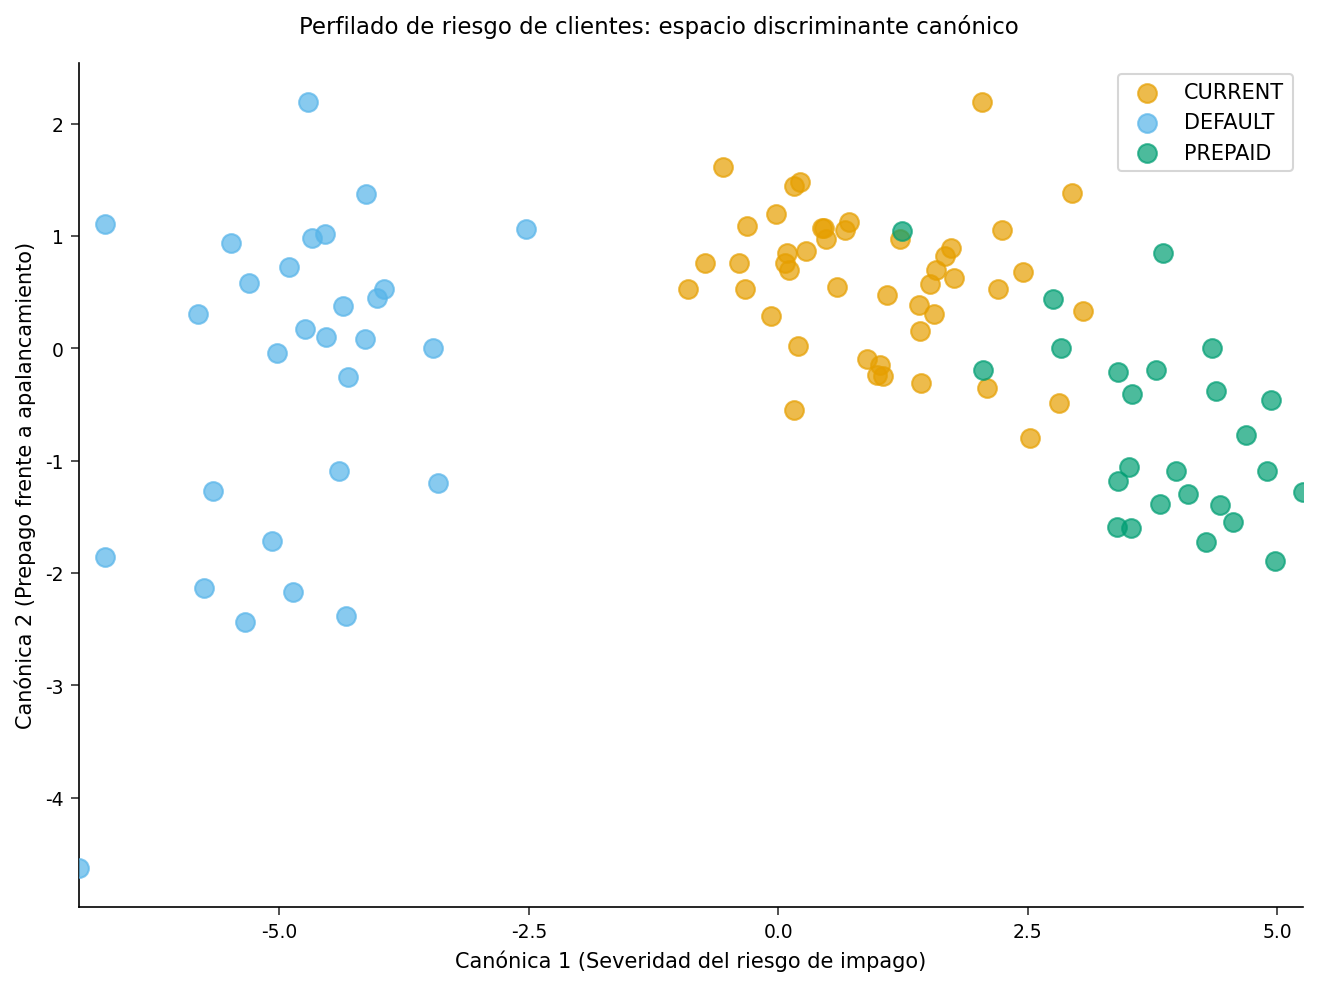

In [7]:
PROCEDIMIENTO SGPLOT DATOS=work.risk_scores;
    SCATTER x=Can1 y=Can2 / GROUP=loan_status
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS ETIQUETA='Canónica 1 (Severidad del riesgo de impago)';
    YAXIS ETIQUETA='Canónica 2 (Prepago frente a apalancamiento)';
    TÍTULO 'Perfilado de riesgo de clientes: espacio discriminante canónico';
EJECUTAR;

---

### Interpretación

Las dos dimensiones canónicas separan nítidamente los tres grupos de estado del préstamo dentro de esta muestra de 100 clientes (46 current, 29 defaulted, 25 prepaid).

**Dimensión 1 — severidad del riesgo de impago (correlación canónica 0.958, 91.8% de varianza compartida).** Este eje por sí solo explica la abrumadora mayoría de la separación entre grupos (autovalor 11.20 frente a 0.34 del segundo eje). En la estructura canónica intragrupo agrupada carga con mayor fuerza sobre la utilización de crédito (-0.595), la relación deuda-ingreso (-0.404), el LTV (-0.370), los meses en mora (-0.324) y la relación pago-ingreso (-0.304): todas las medidas de apalancamiento y carga apuntan en la misma dirección. Como las cargas son negativas, las puntuaciones Can1 bajas (más negativas) marcan a los prestatarios de mayor riesgo. Los centroides de clase lo confirman: las cuentas defaulted se sitúan en Can1 = -4.83, las current en +0.96 y las prepaid en +3.84, un ordenamiento monótono limpio de peor a mejor salud crediticia.

**Dimensión 2 — apalancamiento frente a morosidad (correlación canónica 0.503).** El segundo eje contrasta la relación LTV (+0.733) con los meses en mora (-0.700): separa a los prestatarios muy apalancados pero al corriente de los que arrastran morosidad. Refina la imagen dentro de Can1 pero aporta mucha menos separación, como muestran los centroides Can2 casi iguales de los grupos con buen desempeño (current +0.599, prepaid -0.736).

**Separación de grupos.** Las distancias de Mahalanobis al cuadrado entre las medias de clase cuantifican las brechas: DEFAULT-a-PREPAID es la mayor, con 75.3; DEFAULT-a-CURRENT es 34.3; y CURRENT-a-PREPAID es la menor, con 10.1. Por lo tanto, los dos grupos con buen desempeño están más cerca entre sí que cualquiera de ellos del grupo en impago, exactamente como esperaría un prestamista.

**Uso práctico.** La primera puntuación canónica se comporta como un índice de riesgo compuesto ya preparado: comprime seis ratios correlacionados en una única dimensión bien separada que ordena a los clientes de mayor a menor riesgo de impago. Los equipos de cartera pueden segmentar sobre puntos de corte de Can1, y las distancias de Mahalanobis ofrecen una base fundamentada para asignar a un nuevo solicitante al grupo de estado más cercano durante la calibración del scorecard.

---

### Exportar para el motor de scoring

Persistir las puntuaciones canónicas por cliente y el conjunto de datos de estadísticos canónicos (que porta los centroides y las distancias de Mahalanobis) para la calibración posterior del scorecard.

In [8]:
/* --------------------------------------------------------
   Exportar puntuaciones canónicas de riesgo y estadísticos canónicos
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>